### Stochastic Model Functions

In [5]:
import numpy as np
import matplotlib.pyplot as plt

def process_probabilities(state, params):
    X,Y,Z = state['X'], state['Y'], state['Z']
    a = np.zeros(6)   
    a[0] = (params['beta'] * X*Y)/(X+Y+Z)# Transmission rate
    a[1] = params['gamma'] * Y# Recovery Rates
    a[2] = params['mu']*(X+Y+Z) #Birth
    a[3] = params['mu']*(X)
    a[4] = params['mu']*(Y)
    a[5] = params['mu']*(Z)
    return a

def process(probs):
    r = np.random.random() * sum(probs)
    which = 0
    cumulative_sum = probs[0]    
    while r > cumulative_sum:
        which += 1
        cumulative_sum += probs[which]
    return which + 1


### Plot Results for the Stochastic Model

In [7]:
def plot_results(meanTime, meanS, meanI, meanR):
    plt.figure(figsize=(10, 6))      
    plt.plot(meanTime, meanS, label='Susceptible', linestyle='-')
    plt.plot(meanTime, meanI, label='Infected', linestyle='-')
    plt.plot(meanTime, meanR, label='Recovered', linestyle='-')
    plt.xlabel('Time')
    plt.ylabel('Population')
    plt.title('Mean SIR Model Simulation')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


### Function to Simulate a Stochastic Model 

In [9]:
def SIR_stoch(params, initial, end_time):
    state = initial.copy()
    time = 0
    result = {'time': [], 'X': [], 'Y': [], 'Z': []}
    while time < end_time and state['Y'] > 0:
        
        probs = process_probabilities(state, params)
        tau = (1 / sum(probs)) * np.log(1 / np.random.random())
        time += tau
        which = process(probs)

        if which == 1:
            state['X'] -= 1  # infection
            state['Y'] += 1
        elif which == 2:
            state['Y'] -= 1  # recovery
            state['Z'] += 1
        elif which == 3:  # Birth event
            state['X'] += 1 
        elif which ==4:
            state['X']-=1
        elif which ==5:
            state['Y']-=1
        elif which ==6:
            state['Z']-=1

        result['time'].append(time)
        result['X'].append(state['X'])
        result['Y'].append(state['Y'])
        result['Z'].append(state['Z'])    
    return result


### Function to run a Stochastic Model Simulation over many Iterations

In [95]:
def SIR_stoch_run():
    params = {
        'beta': 1,  
        'gamma': 0.1,
        'mu':0.02/365
    }
    initial = {
        'X': 9999,     
        'Y': 1,     
        'Z': 0      
    }
    
    end_time = 50  # end of simulation time span starting at 0
    run_count = 50 # number of runs
    result = {'time': [], 'X': [], 'Y': [], 'Z': []}
    for n in range(run_count):
        out = SIR_stoch(params, initial, end_time)
        result['time'].extend(out['time'])
        result['X'].extend(out['X'])
        result['Y'].extend(out['Y'])
        result['Z'].extend(out['Z'])
    
    #Extract all the unique time points from the simulations 
    time, unique_indices = np.unique(result['time'], return_index=True)
    X = np.array(result['X'])[unique_indices]
    Y = np.array(result['Y'])[unique_indices]
    Z = np.array(result['Z'])[unique_indices]
 
    N = 100
    meanTime, meanS, meanI, meanR = [], [], [], []
    for i in range(0, len(time) - N + 1, N):
        meanTime.append(np.mean(time[i:i+N]))
        meanS.append(np.mean(X[i:i+N]))
        meanI.append(np.mean(Y[i:i+N]))
        meanR.append(np.mean(Z[i:i+N]))    
    plot_results(meanTime, meanS, meanI, meanR)

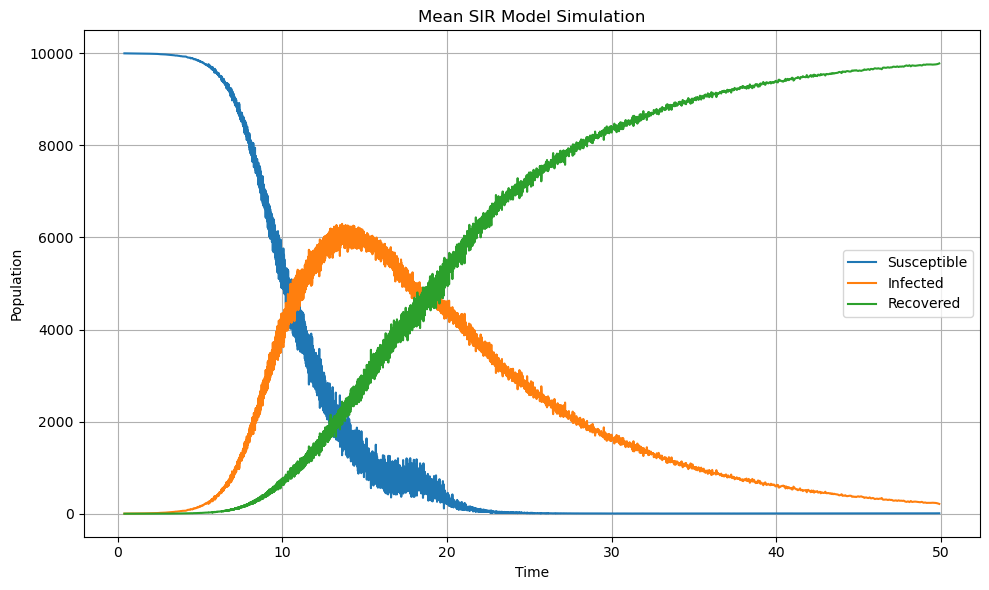

In [111]:
SIR_stoch_run()

### Deterministic SIR Model 

In [59]:
from scipy.integrate import odeint

def SIR_deterministic(y, t, beta, gamma,mu):
    X,Y,Z = y
    N=X+Y+Z
    dXdt = -beta * X*Y/N + mu*N-mu*X
    dYdt = beta * X*Y/N - gamma * Y-mu*Y
    dZdt = gamma * Y-mu*Z
    return [dXdt, dYdt, dZdt]

### Function to Plot Comparison between Stochastic and Deterministic Model 

In [47]:
def plot_comparison(meanTime, meanS, meanI, meanR, t_d, X_d, Y_d, Z_d):
    plt.figure(figsize=(12, 8))      

    plt.subplot(3, 1, 1)
    plt.plot(meanTime, meanS, label='Stochastic (Mean Susceptible)', linestyle='-')
    plt.plot(t_d, X_d, label='Deterministic Susceptible', linestyle='--')
    plt.ylabel('Population (X)')
    plt.legend()

    plt.subplot(3, 1, 2)
    plt.plot(meanTime, meanI, label='Stochastic (Mean Infected)', linestyle='-')
    plt.plot(t_d, Y_d, label='Deterministic Infected', linestyle='--')
    plt.ylabel('Population (Y)')
    plt.legend()

    plt.subplot(3, 1, 3)
    plt.plot(meanTime, meanR, label='Stochastic (Mean Recovered)', linestyle='-')
    plt.plot(t_d, Z_d, label='Deterministic Recovered', linestyle='--')
    plt.xlabel('Time')
    plt.ylabel('Population (Z)')
    plt.legend()

    plt.tight_layout()
    plt.show()


### Function to Compare Stochastic and Deterministic Model 

In [89]:
def compare_stochastic_deterministic_SIR(X=999):
    params = {
        'beta': 1,
        'gamma': 0.1,
        'mu':0.02/365
    }
    initial_stoch = {
        'X': X,
        'Y': 1,
        'Z': 0
    }
    initial_det = [X, 1, 0]
    
    end_time = 50  # end of simulation time span starting at 0

    # Run stochastic simulation
    stoch_results = SIR_stoch(params, initial_stoch, end_time)

    # Prepare time points for deterministic model
    time_points = np.linspace(0, end_time, 100)

    # Run deterministic model
    det_results = odeint(SIR_deterministic, initial_det, time_points, args=(params['beta'], params['gamma'], params['mu']))
    
    # Plotting the results
    plt.figure(figsize=(10, 6))
    plt.plot(stoch_results['time'], stoch_results['X'], label='Stochastic Susceptible', color='blue', linestyle='-')
    plt.plot(stoch_results['time'], stoch_results['Y'], label='Stochastic Infected', color='red', linestyle='-')
    plt.plot(stoch_results['time'], stoch_results['Z'], label='Stochastic Recovered', color='green', linestyle='-')
    
    plt.plot(time_points, det_results[:, 0], label='Deterministic Susceptible', color='blue', linestyle='--')
    plt.plot(time_points, det_results[:, 1], label='Deterministic Infected', color='red', linestyle='--')
    plt.plot(time_points, det_results[:, 2], label='Deterministic Recovered', color='green', linestyle='--')
    
    plt.xlabel('Time')
    plt.ylabel('Population')
    plt.title('Comparison of Stochastic and Deterministic SIR Models')
    plt.legend()
    plt.grid()
    plt.tight_layout()
    plt.show()


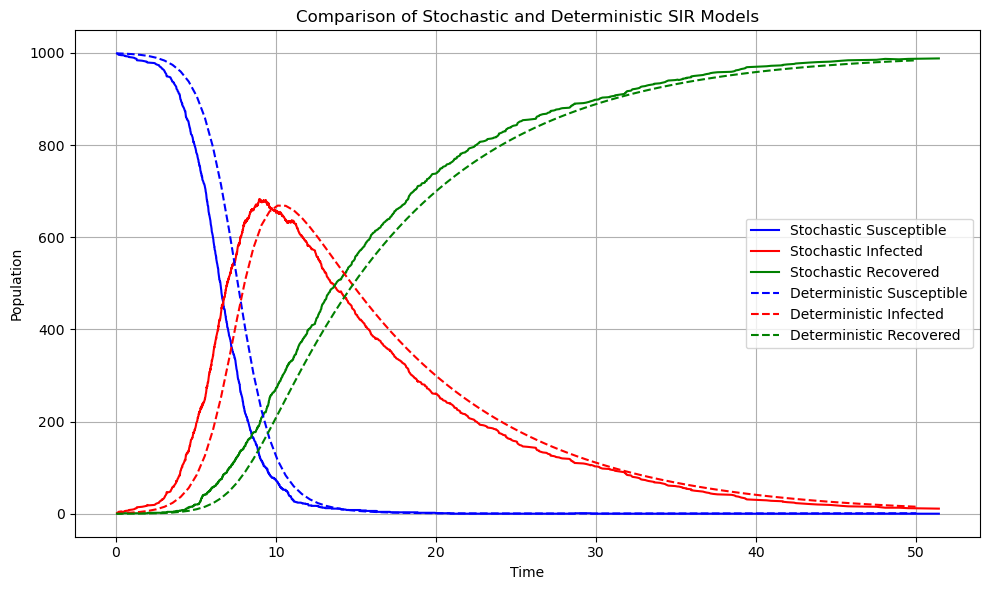

In [109]:
compare_stochastic_deterministic_SIR()

In [ ]:
def run_

1. Run the stochastic multiple times 

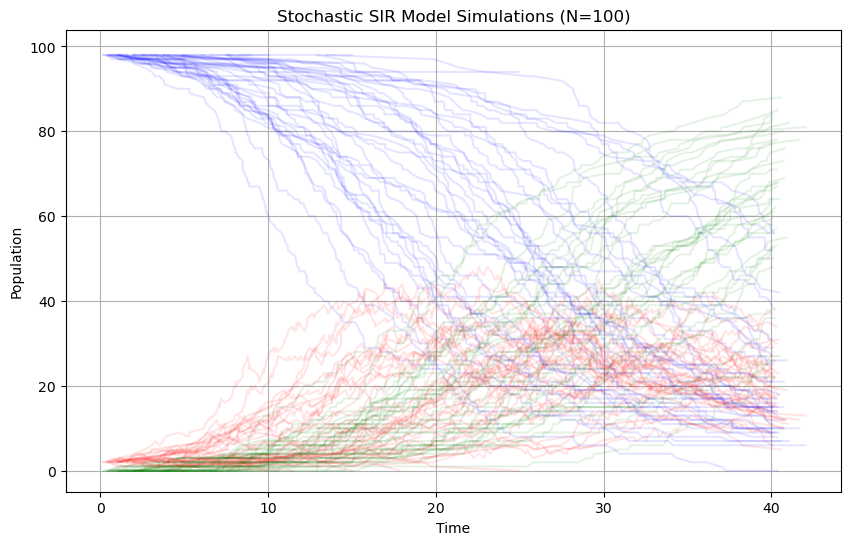

In [212]:

def run_and_plot_stochastic_simulations():
    params = {
        'beta': 0.3,  
        'gamma': 0.1    
    }
    initial = {
        'S': 99,     
        'I': 1,     
        'R': 0      
    }
    
    end_time = 40  # end of simulation time span starting at 0
    run_count = 50  # number of runs

    plt.figure(figsize=(10, 6))  # Create a new figure

    for n in range(run_count):
        out = SIR_stoch(params, initial, end_time)
        plt.plot(out['time'], out['S'], color='blue', alpha=0.1)  # Susceptible
        plt.plot(out['time'], out['I'], color='red', alpha=0.1)   # Infected
        plt.plot(out['time'], out['R'], color='green', alpha=0.1)  # Recovered
    
    plt.xlabel('Time')
    plt.ylabel('Population')
    plt.title(f'Stochastic SIR Model Simulations (N={initial["S"] + initial["I"]})')
    plt.grid(True)
    plt.show()

run_and_plot_stochastic_simulations()

In [132]:
# Block 6: New Function to Vary Parameters and Calculate Covariance
def analyze_parameter_effects():
    beta_values = [0.1, 0.3, 0.5]  # Different infection rates
    N_values = [100, 1000, 10000]  # Different population sizes
    initial_infected = 1
    end_time = 50  # Duration of the simulation
    run_count = 50  # Number of simulations

    for beta in beta_values:
        for N in N_values:
            params = {'beta': beta, 'gamma': 0.1}  # Use fixed recovery rate
            initial = {'S': N - initial_infected, 'I': initial_infected, 'R': 0}
            all_I_means = []  # Store mean infected counts from all simulations
            all_S_means = []  # Store mean susceptible counts from all simulations

            for _ in range(run_count):
                out = SIR_stoch(params, initial, end_time)  # Run the stochastic simulation
                # Store the mean of the infected and susceptible populations
                all_I_means.append(np.mean(out['I']))  # Mean infected population
                all_S_means.append(np.mean(out['S']))  # Mean susceptible population

            # Calculate the covariance between the means of S and I
            S_mean = np.mean(all_S_means,axis=0)
            I_mean = np.mean(all_I_means,axis=0)
            covariance = np.cov(all_S_means, all_I_means)[0][1]

            print(f"Beta: {beta}, N: {N}, Covariance between mean S and mean I: {covariance:.2f}")

# Block 7: Call the new function to analyze parameter effects
analyze_parameter_effects()


Beta: 0.1, N: 100, Covariance between mean S and mean I: -73.20
Beta: 0.1, N: 1000, Covariance between mean S and mean I: 0.05
Beta: 0.1, N: 10000, Covariance between mean S and mean I: 1.44
Beta: 0.3, N: 100, Covariance between mean S and mean I: -0.13
Beta: 0.3, N: 1000, Covariance between mean S and mean I: 0.04
Beta: 0.3, N: 10000, Covariance between mean S and mean I: 1.95
Beta: 0.5, N: 100, Covariance between mean S and mean I: -0.05
Beta: 0.5, N: 1000, Covariance between mean S and mean I: 0.11
Beta: 0.5, N: 10000, Covariance between mean S and mean I: 2.10


In [128]:
def analyze_transients():
    beta_values = [0.1, 0.3, 0.5]  # Varying infection rates
    N_values = [100, 500, 1000]     # Varying population sizes
    initial_infected = 1
    end_time = 100  # Duration of the simulation
    run_count = 50  # Number of simulations

    results = []  # Store results for plotting

    for beta in beta_values:
        for N in N_values:
            params = {'beta': beta, 'gamma': 0.1}  # Fixed recovery rate
            initial = {'S': N - initial_infected, 'I': initial_infected, 'R': 0}
            max_infected_vals = []

            for _ in range(run_count):
                out = SIR_stoch(params, initial, end_time)
                max_infected_vals.append(out['max_infected'])

            # Calculate mean of maximum infected populations
            mean_max_infected = np.mean(max_infected_vals)
            results.append((beta, N, mean_max_infected))
            print(f"Beta: {beta}, N: {N}, Mean Max Infected: {mean_max_infected:.2f}")

    return results

# Block 3: Function to Plot Results
def plot_transients(results):
    betas = [r[0] for r in results]
    N_values = [r[1] for r in results]
    max_infected = [r[2] for r in results]

    plt.figure(figsize=(12, 6))
    scatter = plt.scatter(N_values, max_infected, c=betas, cmap='viridis', s=100)
    plt.colorbar(scatter, label='Beta')
    plt.xlabel('Population Size (N)')
    plt.ylabel('Mean Max Infected Population')
    plt.title('Mean Maximum Infected Population vs Population Size with Varying Beta')
    plt.grid()
    plt.tight_layout()
    plt.show()


In [130]:
results = analyze_transients()
plot_transients(results)

KeyError: 'max_infected'

/var/folders/_1/0wm31tv93_g2x0n62x6b_ht80000gn/T/ipykernel_98485/2885699929.py:23: ODEintWarning: Excess work done on this call (perhaps wrong Dfun type). Run with full_output = 1 to get quantitative information.
  det_results = odeint(SIR_deterministic, initial_det, time_points, args=(params['beta'], params['gamma'],params['mu']))


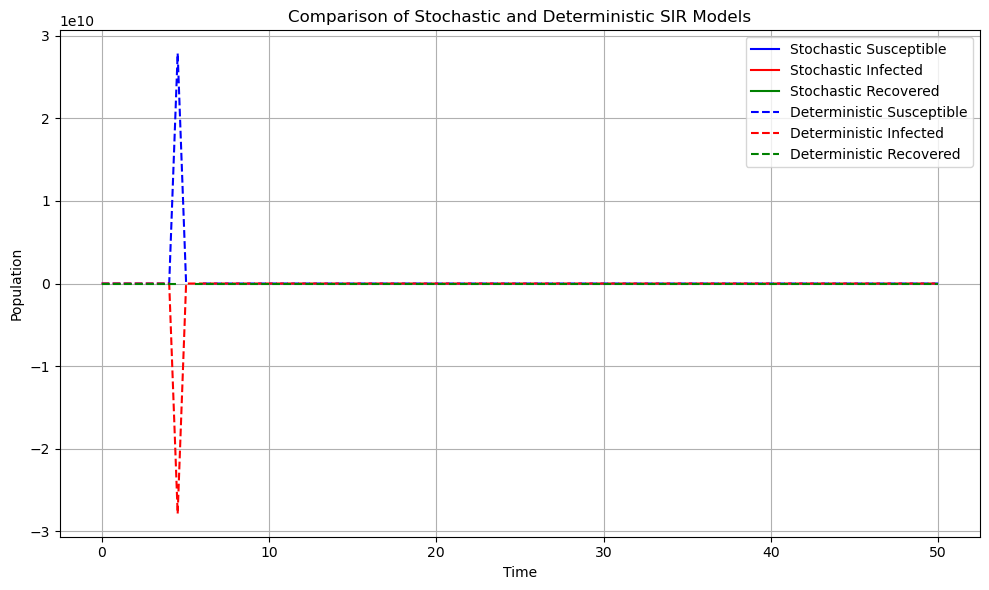

In [57]:
def compare_stochastic_deterministic_SIR():
    params = {
        'beta': 0.3,  # Adjusted beta
        'gamma': 0.1,
        'mu': 0.02/365
    }
    initial_stoch = {
        'X': 9999,
        'Y': 1,
        'Z': 0
    }
    initial_det = [9999, 1, 0]
    
    end_time = 50  # end of simulation time span starting at 0

    # Run stochastic simulation
    stoch_results = SIR_stoch(params, initial_stoch, end_time)

    # Prepare time points for deterministic model
    time_points = np.linspace(0, end_time, 100)

    # Run deterministic model
    det_results = odeint(SIR_deterministic, initial_det, time_points, args=(params['beta'], params['gamma'],params['mu']))
    
    # Plotting the results
    plt.figure(figsize=(10, 6))
    plt.plot(stoch_results['time'], stoch_results['X'], label='Stochastic Susceptible', color='blue', linestyle='-')
    plt.plot(stoch_results['time'], stoch_results['Y'], label='Stochastic Infected', color='red', linestyle='-')
    plt.plot(stoch_results['time'], stoch_results['Z'], label='Stochastic Recovered', color='green', linestyle='-')
    
    plt.plot(time_points, det_results[:, 0], label='Deterministic Susceptible', color='blue', linestyle='--')
    plt.plot(time_points, det_results[:, 1], label='Deterministic Infected', color='red', linestyle='--')
    plt.plot(time_points, det_results[:, 2], label='Deterministic Recovered', color='green', linestyle='--')
    
    plt.xlabel('Time')
    plt.ylabel('Population')
    plt.title('Comparison of Stochastic and Deterministic SIR Models')
    plt.legend()
    plt.grid()
    plt.tight_layout()
    plt.show()
compare_stochastic_deterministic_SIR()